# Phase 2: Decoding Movement Intent from EEG

In Phase 1 we cleaned the recording and saw that imagining a fist movement changes the mu and beta rhythms over the motor cortex. Now we ask the harder question: **can a model look at one trial of brain signal and tell which hand was imagined?**

![Pipeline](../images/bci_pipeline.png)

This phase has four steps:

1. Reload and prepare the trials (same steps as Phase 1)
2. Turn each trial into a small set of useful numbers (**features**)
3. Train a classifier on those features
4. Test it honestly on trials it has never seen

**An honest expectation:** with real brain data from one person, accuracy is rarely perfect. Chance for two classes is 50%, and typical results for this kind of task are well above that but far from 100%. Reporting a realistic number is part of doing this properly.

In [1]:
import numpy as np                                   # numerical arrays
import matplotlib.pyplot as plt                      # plotting
import mne                                           # EEG loading and processing
from mne.datasets import eegbci                      # PhysioNet motor imagery dataset
from mne.io import concatenate_raws, read_raw_edf    # reading and combining recordings
from mne.decoding import CSP                         # Common Spatial Patterns (spatial feature extractor)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # simple linear classifier
from sklearn.pipeline import Pipeline                # chains feature extraction + classifier
from sklearn.model_selection import StratifiedKFold, cross_val_score  # honest accuracy testing

np.random.seed(42)
mne.set_log_level("WARNING")
print(f"MNE version: {mne.__version__}")

MNE version: 1.13.2


## Step 1: Reload and Prepare the Trials

Each notebook should run on its own, so we repeat the loading, filtering and epoching from Phase 1 here. Nothing new yet:

- Load subject 1's three imagery runs (left fist vs. right fist)
- Bandpass filter to 8–30 Hz, where the mu and beta rhythms live
- Cut the recording into 5-second trials around each cue

Each trial gets a label: `left` or `right`. That label is the answer the classifier will try to predict.

In [2]:
# load subject 1's imagery runs (4, 8, 12 = left vs. right fist imagery)
subject = 1
imagery_runs = [4, 8, 12]
file_paths = eegbci.load_data(subject, imagery_runs)
raws = [read_raw_edf(path, preload=True) for path in file_paths]
raw = concatenate_raws(raws)
eegbci.standardize(raw)
raw.set_montage(mne.channels.make_standard_montage("colin27_1005"))

# bandpass filter to the mu + beta range
raw_filt = raw.copy().filter(l_freq=8.0, h_freq=30.0, verbose=False)

# find the cues: T1 = imagine left fist, T2 = imagine right fist
events, _ = mne.events_from_annotations(raw_filt, event_id={"T1": 2, "T2": 3}, verbose=False)

# cut into trials: 1 s before the cue to 4 s after
epochs = mne.Epochs(
    raw_filt, events, event_id={"left": 2, "right": 3},
    tmin=-1.0, tmax=4.0, baseline=None, picks="eeg",
    preload=True, verbose=False,
)

X = epochs.get_data()          # shape: (trials, channels, time samples)
y = epochs.events[:, 2]        # label for each trial (2 = left, 3 = right)

print(f"X shape: {X.shape}")
print(f"Left trials:  {np.sum(y == 2)}")
print(f"Right trials: {np.sum(y == 3)}")

/Users/victordeni/brain-controlled-robotic-arm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X shape: (45, 64, 801)
Left trials:  23
Right trials: 22


## Step 2: Why Raw EEG Isn't Enough, and What CSP Does

We could hand all 64 channels × 801 time points (about 51,000 numbers) to a classifier. But we only have 45 trials. A model with that many inputs and so few examples would memorize the noise instead of learning anything real. We need to boil each trial down to a handful of meaningful numbers.

Look at what the earlier plots showed: the information is in **how strong** the mu/beta rhythm is, not in the exact wiggles. Imagining the left fist weakens the rhythm over one part of the motor cortex, and the right fist over the other. So the useful feature is **signal power** in the right spatial mix of channels.

![CSP concept](../images/csp_concept.png)

**Common Spatial Patterns (CSP)** finds that mix automatically.

**The math, simply:**

1. For each class, compute the channel covariance matrix, averaged over its trials. Call them $\Sigma_L$ (left) and $\Sigma_R$ (right). Each is a 64×64 table that records how the channels vary together.
2. A spatial filter $w$ is a list of 64 weights. The new signal is $w^\top x$, a weighted sum of the channels. Its variance (power) for class L is $w^\top \Sigma_L w$.
3. CSP picks the filters that **maximize the ratio** between the classes:

$$\max_w \; \frac{w^\top \Sigma_L \, w}{w^\top \Sigma_R \, w}$$

   A big ratio means the filter's signal is strong during left trials and weak during right trials. The opposite extreme works for right trials.
4. This is solved as a standard eigenvalue problem: $\Sigma_L w = \lambda (\Sigma_L + \Sigma_R) w$. The eigenvectors at the two ends of the spectrum are our best filters.
5. For each trial, we apply the filters and take the **log of the variance** of each output. The log makes the numbers better behaved. A few filters give a handful of features per trial.

**Important:** CSP uses the labels to learn its filters, so it must be fit only on training trials, never on the test trials. Otherwise the accuracy would be inflated. We'll handle that correctly in the cross-validation step.

In [3]:
# Keep only the imagery window: skip the first 0.5 s (cue reaction) and the last second
epochs_win = epochs.copy().crop(tmin=0.5, tmax=3.5)

X = epochs_win.get_data()      # shape: (trials, channels, time samples)
y = epochs_win.events[:, 2]    # 2 = left, 3 = right

print(f"X shape: {X.shape}")
print(f"Window: {epochs_win.tmin:.1f} s to {epochs_win.tmax:.1f} s after the cue")

X shape: (45, 64, 481)
Window: 0.5 s to 3.5 s after the cue


## Step 3: Train a Classifier and Test It Honestly

**The classifier.** After CSP, each trial is just a few numbers. We use **Linear Discriminant Analysis (LDA)**, a simple, well-tested choice for small EEG datasets. It draws the best straight dividing line (a hyperplane in more dimensions) between the left features and the right features. For a trial with features $f$, it computes a score:

$$s = w^\top f + b$$

If $s > 0$ it predicts one hand, otherwise the other. LDA picks $w$ so that the two classes' averages are far apart relative to how spread out each class is.

**The honest test.** If we trained and tested on the same trials, the score would look great and mean nothing. So we use **cross-validation**:

1. Split the 45 trials into 5 groups ("folds").
2. Train on 4 folds, test on the 1 left out.
3. Repeat so every fold gets a turn as the test set.
4. Repeat the whole thing 10 times with different random splits, and average.

Crucially, CSP is placed *inside* the pipeline, so in every fold it learns its filters from the training trials only. The test trials stay completely unseen.

**Chance level:** with 23 left and 22 right trials, always guessing "left" gives about 51%. Anything meaningfully above that means the model found real signal.

In [4]:
from sklearn.model_selection import RepeatedStratifiedKFold

# CSP (learns spatial filters) -> LDA (draws the dividing line)
clf = Pipeline([
    ("csp", CSP(n_components=4, reg=None, log=True)),   # 4 filters -> 4 log-variance features
    ("lda", LinearDiscriminantAnalysis()),
])

# 5 folds, repeated 10 times with different random splits = 50 train/test runs
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")

chance = max(np.mean(y == 2), np.mean(y == 3))
print(f"Cross-validated accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Chance level (always guess the larger class): {chance:.3f}")
print(f"Best fold: {scores.max():.3f}   Worst fold: {scores.min():.3f}")

Cross-validated accuracy: 0.718 ± 0.170
Chance level (always guess the larger class): 0.511
Best fold: 1.000   Worst fold: 0.444


## Step 4: How Stable Is the Score, and What Did CSP Learn?

A single accuracy number hides a lot. With only 45 trials, each test fold holds about 9 trials, so one extra right or wrong guess moves that fold's score by roughly 11 percentage points. Two plots will show the full picture:

1. **The spread of all 50 cross-validation scores**, compared with chance
2. **The spatial patterns CSP learned**, drawn on a head map. If the method found something real, the patterns should point at the motor cortex (around C3, Cz and C4) and not at random electrodes.

*Note:* for the head map only, we fit CSP on all trials, because we are inspecting the filters and not measuring accuracy. The accuracy above never saw its test trials during fitting.

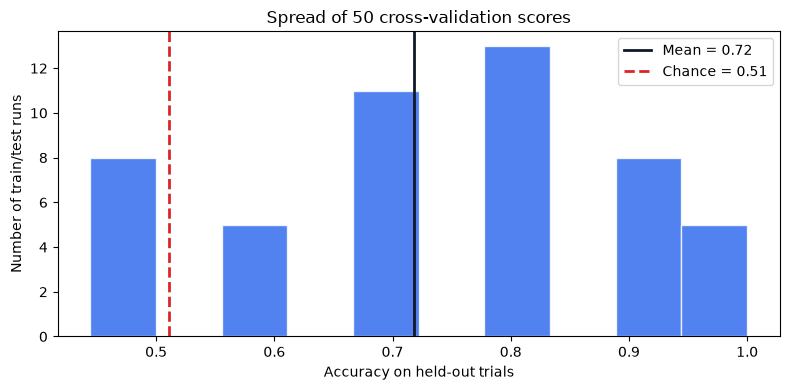

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(scores, bins=10, color="#2563eb", alpha=0.8, edgecolor="white")
ax.axvline(scores.mean(), color="#111827", linewidth=2, label=f"Mean = {scores.mean():.2f}")
ax.axvline(chance, color="#dc2626", linewidth=2, linestyle="--", label=f"Chance = {chance:.2f}")

ax.set_xlabel("Accuracy on held-out trials")
ax.set_ylabel("Number of train/test runs")
ax.set_title("Spread of 50 cross-validation scores")
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/5c/tbs3rzhx5nld4zff5wp02ywh0000gn/T/ipykernel_86574/204090325.py:5: RuntimeWarning: More than 25 topomaps plots requested. This might take a while.
  csp_view.plot_patterns(






In [6]:
# Fit CSP on all trials ONLY to look at the patterns (not to measure accuracy)
csp_view = CSP(n_components=4, reg=None, log=True)
csp_view.fit(X, y)

csp_view.plot_patterns(
    epochs_win.info, ch_type="eeg", units="Pattern (a.u.)", size=1.5
)

## Step 5: Is 72% Real, or Luck?

With 45 trials, a good-looking score could happen by chance. A **permutation test** checks this directly:

1. Randomly shuffle the left/right labels, which destroys any real link between the brain signal and the label.
2. Run the same cross-validation and record the accuracy.
3. Repeat 100 times. This builds the distribution of scores we'd get *with no real signal*.
4. The **p-value** is the fraction of shuffled runs that score at least as high as our real result. A small p-value means our result is very unlikely to be luck.

Real accuracy:             0.644
Mean shuffled accuracy:    0.494
Best shuffled accuracy:    0.689
p-value:                   0.030


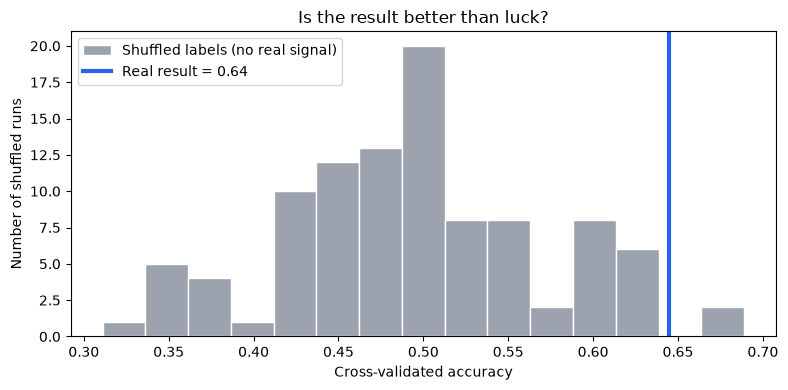

In [7]:
from sklearn.model_selection import permutation_test_score

cv_perm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score, perm_scores, p_value = permutation_test_score(
    clf, X, y, cv=cv_perm, n_permutations=100, scoring="accuracy",
    random_state=42, n_jobs=1,
)

print(f"Real accuracy:             {score:.3f}")
print(f"Mean shuffled accuracy:    {perm_scores.mean():.3f}")
print(f"Best shuffled accuracy:    {perm_scores.max():.3f}")
print(f"p-value:                   {p_value:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_scores, bins=15, color="#9ca3af", edgecolor="white", label="Shuffled labels (no real signal)")
ax.axvline(score, color="#2563eb", linewidth=3, label=f"Real result = {score:.2f}")
ax.set_xlabel("Cross-validated accuracy")
ax.set_ylabel("Number of shuffled runs")
ax.set_title("Is the result better than luck?")
ax.legend()
plt.tight_layout()
plt.show()

## Reading the Result (Subject 1)

- **Cross-validated accuracy: 71.8% ± 17.0%** (10× repeated 5-fold), versus 51.1% chance
- **Permutation test: p = 0.030.** Shuffling the labels almost never reproduces our score, so the decoding is unlikely to be luck.
- **The score is noisy.** With 45 trials, each test fold holds about 9 trials, so a single fold can land anywhere from 44% to 100%. A single fixed 5-fold split gave 64.4%, a reminder that one subject's number shouldn't be over-trusted.

The signal is real but modest, and that is typical for single-subject, non-invasive BCI. The next step is to check whether it holds up across several people.

## Step 6: Does It Hold Up Across People?

Brain signals differ a lot between individuals. We now repeat the whole pipeline for subjects 1–10, **training and testing separately within each person**. This is the standard way to evaluate a BCI. It tells us how well the method works in general, and how much the result depends on who is wearing the cap.

Subject  1: 0.711  (45 trials)


Subject  2: 0.889  (45 trials)


Subject  3: 0.622  (45 trials)


Subject  4: 0.519  (45 trials)


Subject  5: 0.496  (45 trials)


Subject  6: 0.444  (45 trials)


Subject  7: 0.978  (45 trials)


Subject  8: 0.459  (45 trials)


Subject  9: 0.393  (45 trials)


Subject 10: 0.459  (45 trials)

Mean across subjects: 0.597 ± 0.191


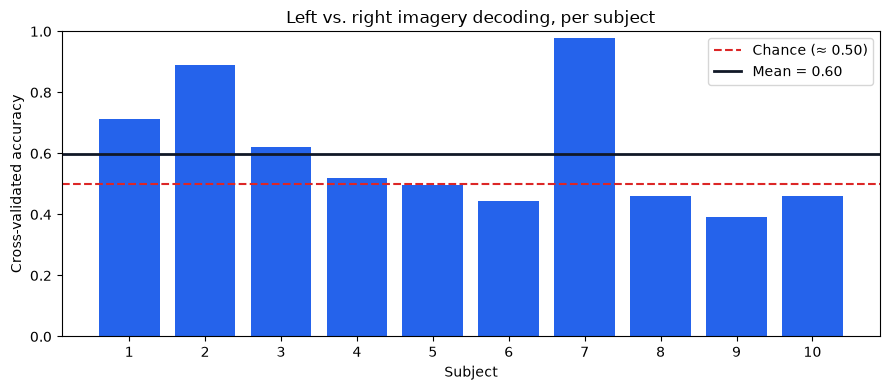

In [8]:
def load_subject(subject):
    """Load, filter, epoch, and crop one subject's left/right imagery trials."""
    paths = eegbci.load_data(subject, [4, 8, 12])
    raw = concatenate_raws([read_raw_edf(p, preload=True) for p in paths])
    eegbci.standardize(raw)
    raw.filter(l_freq=8.0, h_freq=30.0, verbose=False)
    events, _ = mne.events_from_annotations(raw, event_id={"T1": 2, "T2": 3}, verbose=False)
    ep = mne.Epochs(raw, events, event_id={"left": 2, "right": 3}, tmin=-1.0, tmax=4.0,
                    baseline=None, picks="eeg", preload=True, verbose=False)
    ep.crop(tmin=0.5, tmax=3.5)
    return ep.get_data(), ep.events[:, 2]

subjects = list(range(1, 11))
cv_multi = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

subject_acc = {}
for s in subjects:
    Xs, ys = load_subject(s)
    acc = cross_val_score(clf, Xs, ys, cv=cv_multi, scoring="accuracy")
    subject_acc[s] = acc.mean()
    print(f"Subject {s:2d}: {acc.mean():.3f}  ({len(ys)} trials)")

accs = np.array(list(subject_acc.values()))
print(f"\nMean across subjects: {accs.mean():.3f} ± {accs.std():.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([str(s) for s in subjects], accs, color="#2563eb")
ax.axhline(0.5, color="#dc2626", linestyle="--", label="Chance (≈ 0.50)")
ax.axhline(accs.mean(), color="#111827", linewidth=2, label=f"Mean = {accs.mean():.2f}")
ax.set_ylim(0, 1)
ax.set_xlabel("Subject")
ax.set_ylabel("Cross-validated accuracy")
ax.set_title("Left vs. right imagery decoding, per subject")
ax.legend()
plt.tight_layout()
plt.show()

## Reading the Result (10 Subjects)

| Group | Subjects | Accuracy |
|---|---|---|
| Strong decoding | 2, 7, 1 | 89%, 98%, 71% |
| Weak decoding | 3 | 62% |
| At chance | 4, 5, 6, 8, 9, 10 | 39–52% |

- **Mean across subjects: 59.7% ± 19.1%** (chance ≈ 50%)
- The spread between people is huge. The ±19% is mostly *who* is wearing the cap, not randomness within one person.
- Scores slightly below 50% (subjects 6, 8, 9, 10) are not meaningfully "worse than chance." With 45 trials, a score has a standard error of about 7 points, so these are consistent with no decodable signal.
- This matches what BCI research reports: for a sizable minority of people, left-vs-right motor imagery doesn't produce a strong enough pattern for a simple method like CSP + LDA.

**What this means for the rest of the project:** a robotic arm controlled by this decoder would work well for some users and poorly for others. For the demo in Phases 3 and 4, we'll use a subject whose signal decodes well, and we'll say so openly, alongside this table of all ten.

## Step 7: Can Regularization Help?

CSP estimates two 64×64 covariance matrices from only about 36 training trials per fold. That's far too little data for 64 channels (2,016 unique numbers per matrix), so the estimates are noisy and CSP can overfit them.

**Shrinkage** fixes this by pulling the covariance toward a simpler, more stable matrix. The Ledoit–Wolf method chooses the amount of pulling automatically:

$$\hat{\Sigma} = (1-\alpha)\,\Sigma_{\text{sample}} + \alpha\,\mu I$$

where $\mu$ is the average variance and $\alpha \in [0,1]$ is picked from the data. We compare three settings on all 10 subjects, with the same cross-validation as before.

*Note:* we're trying a few settings on the same 10 subjects, so this is exploration, not a clean final test. Any gain should be reported with that caveat.

CSP, no regularization     mean = 0.597
CSP + shrinkage            mean = 0.597
CSP + shrinkage, 6 comp    mean = 0.595


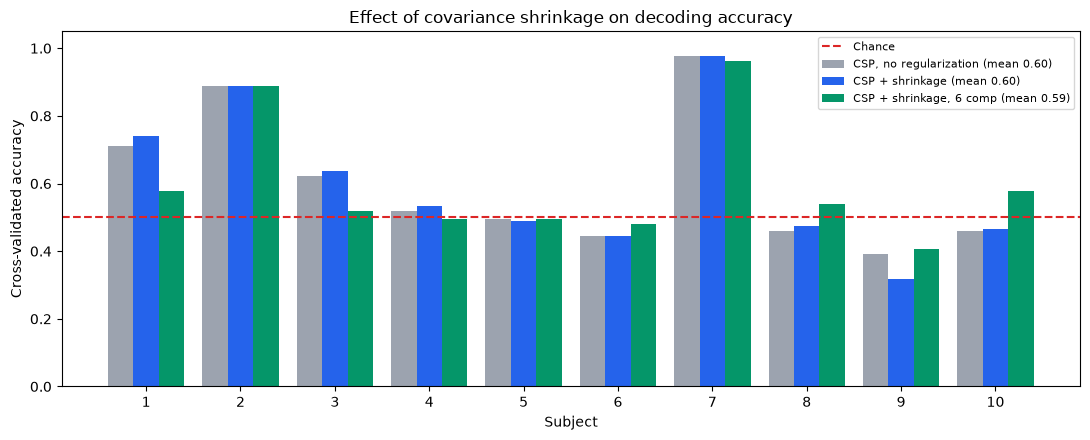

In [9]:

# Load all 10 subjects once (files are already downloaded, so this is fast)
data = {s: load_subject(s) for s in subjects}

configs = {
    "CSP, no regularization":  dict(n_components=4, reg=None),
    "CSP + shrinkage":         dict(n_components=4, reg="ledoit_wolf"),
    "CSP + shrinkage, 6 comp": dict(n_components=6, reg="ledoit_wolf"),
}

results = {}
for name, params in configs.items():
    model = Pipeline([("csp", CSP(log=True, **params)), ("lda", LinearDiscriminantAnalysis())])
    accs_cfg = []
    for s in subjects:
        Xs, ys = data[s]
        accs_cfg.append(cross_val_score(model, Xs, ys, cv=cv_multi, scoring="accuracy").mean())
    results[name] = np.array(accs_cfg)
    print(f"{name:26s} mean = {results[name].mean():.3f}")

# grouped bar chart
fig, ax = plt.subplots(figsize=(11, 4.5))
width = 0.27
colors = ["#9ca3af", "#2563eb", "#059669"]
x = np.arange(len(subjects))
for i, (name, vals) in enumerate(results.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=f"{name} (mean {vals.mean():.2f})", color=colors[i])
ax.axhline(0.5, color="#dc2626", linestyle="--", label="Chance")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in subjects])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Subject")
ax.set_ylabel("Cross-validated accuracy")
ax.set_title("Effect of covariance shrinkage on decoding accuracy")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("../images/subject_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary of Phase 2

**Pipeline:** 8–30 Hz bandpass → 0.5–3.5 s window after the cue → Common Spatial Patterns (4 filters) → Linear Discriminant Analysis, trained and tested within each subject.

| Result | Value |
|---|---|
| Subject 1, 10× repeated 5-fold CV | 71.8% ± 17.0% (chance 51.1%) |
| Subject 1, permutation test | p = 0.030 |
| Mean across subjects 1–10 | 59.7% ± 19.1% |
| Shrinkage-regularized CSP | no improvement (59.5–59.7%) |

**What we learned:**

- The decoder finds real signal for some people (subjects 2, 7, 1) and little or none for others. This large difference between individuals is a well-documented feature of motor-imagery BCIs.
- Adding regularization didn't help, so the limit here is the amount of data and the person's signal, not the covariance estimate.
- A fair headline is not "98% accuracy" but "roughly 60% on average, from chance to near-perfect depending on the person."

**Next:** Phase 3 treats the classifier's trial-by-trial output as a noisy stream and smooths it with a Kalman filter. For that demonstration we'll use a subject whose signal decodes well (subject 7), and we'll keep the table above next to it.